# XGBoost 폭락/급등 전조 신호 탐지기 — 3클래스 분류

## 목적
향후 **20영업일** 내 S&P 500의 **폭락(-10%)** 또는 **급등(+10%)** 발생 가능성을 사전에 감지하는 XGBoost 3클래스 분류 모델.

## 라벨 정의
| 라벨 | 의미 | 조건 |
|------|------|------|
| **0** | 정상 | 향후 20일 내 ±10% 이벤트 없음 |
| **1** | 폭락 전조 | 향후 20일 내 -10% 이하 하락 발생 |
| **2** | 급등 전조 | 향후 20일 내 +10% 이상 상승 발생 |

## 피처 (37개)
- **가격/수익률/추세** (8): 로그수익률 1/5/10/20일, 낙폭 60일, MA 괴리 50/200일, 일중 변동폭
- **실현변동성** (4): RV 5/21일, EWMA λ=0.94, 변동성의 변동성
- **옵션/내재변동성** (6): VIX(ln), VIX 변화, VIX 퍼센타일, VXV-VIX, SKEW, P/C비율
- **신용** (3): HY OAS, BBB OAS, CCC OAS
- **금리** (2): 10년 금리, 장단기 금리차
- **크로스에셋** (2): 달러지수 5일, WTI 5일
- **Tier 2 보조** (12): VIX9D-VIX, VVIX, P/C Equity, VRP, Parkinson, Amihud, 달러거래대금 z-score, 실질금리, BEI, SOFR-EFFR, NFCI, 주식-금리 상관

## 검증 기준
- 홀드아웃 macro F1 > 0.25
- 2008/2020 위기 전 crash_score > 90 (상위 10% percentile)
- 2020-21 반등기 surge_score > 80
- 안정기(2013~2019) 평균 < 55 (percentile 중앙값 근처)

In [60]:
# ── Cell 1: 원시 데이터 수집 ──────────────────────────────────────────
!pip install imbalanced-learn optuna -q

import warnings, time
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import requests
import yfinance as yf
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, average_precision_score,
)
import optuna
from imblearn.over_sampling import SMOTE

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
FRED_BASE = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id='

# ── 헬퍼 ──
def fetch_fred(series_id: str, col_name: str, retries: int = 4, timeout: int = 30) -> pd.DataFrame:
    """FRED CSV 다운로드 (지수 백오프 재시도)."""
    url = FRED_BASE + series_id
    for attempt in range(retries):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=timeout)
            resp.raise_for_status()
            df = pd.read_csv(StringIO(resp.text), index_col=0, parse_dates=True)
            df.columns = [col_name]
            df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            return df
        except Exception:
            if attempt < retries - 1:
                wait = 2 ** attempt
                print(f'  [{series_id}] 재시도 {attempt+1}/{retries} ({wait}초 대기)...')
                time.sleep(wait)
            else:
                raise

def strip_tz(obj):
    """타임존 제거 (Series / DataFrame)."""
    obj = obj.copy()
    if hasattr(obj.index, 'tz') and obj.index.tz is not None:
        obj.index = obj.index.tz_localize(None)
    return obj

# ── 1) SPY OHLCV ──
print('▶ SPY OHLCV 수집...')
spy_raw = yf.Ticker('SPY').history(start='2000-01-01', auto_adjust=True)
spy = strip_tz(spy_raw)[['Open', 'High', 'Low', 'Close', 'Volume']]
print(f'  SPY: {spy.index[0].date()} ~ {spy.index[-1].date()} ({len(spy)}행)')

# ── 2) FRED 12개 시리즈 ──
FRED_MAP = {
    'BAMLH0A0HYM2': 'HY_OAS',
    'BAMLC0A4CBBB': 'BBB_OAS',
    'BAMLH0A3HYC':  'CCC_OAS',
    'DGS10':        'DGS10',
    'T10Y3M':       'T10Y3M',
    'DFII10':       'DFII10',
    'T10YIE':       'T10YIE',
    'SOFR':         'SOFR',
    'EFFR':         'EFFR',
    'NFCI':         'NFCI',
    'DTWEXBGS':     'DTWEXBGS',
    'DCOILWTICO':   'WTI',
}

fred = {}
print('\n▶ FRED 시리즈 수집...')
for sid, col in FRED_MAP.items():
    try:
        fred[col] = fetch_fred(sid, col)
        r = fred[col].dropna()
        print(f'  {col}: {r.index[0].date()} ~ {r.index[-1].date()} ({len(r)}행)')
    except Exception as e:
        print(f'  {col}: 실패 — {e}')
        fred[col] = pd.DataFrame({col: []}, index=pd.DatetimeIndex([]))

# ── 3) Cboe 5개 (yfinance) ──
CBOE_MAP = {'^VIX': 'VIX', '^VIX3M': 'VIX3M', '^VIX9D': 'VIX9D', '^VVIX': 'VVIX', '^SKEW': 'SKEW'}
cboe = {}
print('\n▶ Cboe 지수 수집...')
for ticker, col in CBOE_MAP.items():
    try:
        h = yf.Ticker(ticker).history(start='2000-01-01', auto_adjust=True)
        h = strip_tz(h)
        cboe[col] = h['Close'].rename(col)
        print(f'  {col}: {cboe[col].dropna().index[0].date()} ~ {cboe[col].dropna().index[-1].date()} ({cboe[col].dropna().shape[0]}행)')
    except Exception as e:
        print(f'  {col}: 실패 — {e}')
        cboe[col] = pd.Series(dtype=float, name=col)

# ── 4) Put/Call 비율 ──
print('\n▶ Put/Call 비율 수집...')
putcall = {}
for name, ticker in [('PUTCALL_TOTAL', '^PCALL'), ('PUTCALL_EQUITY', '^EPCALL')]:
    try:
        h = yf.Ticker(ticker).history(start='2000-01-01', auto_adjust=True)
        h = strip_tz(h)
        putcall[name] = h['Close'].rename(name)
        print(f'  {name}: OK ({putcall[name].dropna().shape[0]}행)')
    except Exception as e:
        print(f'  {name}: 실패 (보조 피처로 처리) — {e}')
        putcall[name] = pd.Series(dtype=float, name=name)

print('\n✅ 데이터 수집 완료')
print(f'   SPY: {len(spy)}행')
print(f'   FRED: {sum(len(v.dropna()) for v in fred.values())}행 (12시리즈)')
print(f'   Cboe: {sum(len(v.dropna()) for v in cboe.values())}행 (5지수)')
print(f'   Put/Call: {sum(len(v.dropna()) for v in putcall.values())}행')

You should consider upgrading via the 'C:\Users\82106\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


▶ SPY OHLCV 수집...
  SPY: 2000-01-03 ~ 2026-03-09 (6584행)

▶ FRED 시리즈 수집...
  HY_OAS: 1996-12-31 ~ 2026-03-06 (7620행)
  BBB_OAS: 1996-12-31 ~ 2026-03-06 (7620행)
  CCC_OAS: 1996-12-31 ~ 2026-03-06 (7620행)
  DGS10: 1962-01-02 ~ 2026-03-05 (16027행)
  T10Y3M: 1982-01-04 ~ 2026-03-06 (11045행)
  DFII10: 2003-01-02 ~ 2026-03-05 (5796행)
  T10YIE: 2003-01-02 ~ 2026-03-06 (5797행)
  SOFR: 2018-04-03 ~ 2026-03-06 (1979행)
  EFFR: 2000-07-03 ~ 2026-03-06 (6445행)
  NFCI: 1971-01-08 ~ 2026-02-27 (2878행)
  DTWEXBGS: 2006-01-02 ~ 2026-02-27 (5052행)
  WTI: 1986-01-02 ~ 2026-03-02 (10109행)

▶ Cboe 지수 수집...
  VIX: 2000-01-03 ~ 2026-03-09 (6584행)
  VIX3M: 2006-07-17 ~ 2026-03-09 (4942행)
  VIX9D: 2011-01-03 ~ 2026-03-09 (3817행)
  VVIX: 2007-01-03 ~ 2026-03-09 (4816행)


$^PCALL: possibly delisted; no timezone found
$^EPCALL: possibly delisted; no timezone found


  SKEW: 2000-01-03 ~ 2026-03-06 (6510행)

▶ Put/Call 비율 수집...
  PUTCALL_TOTAL: OK (0행)
  PUTCALL_EQUITY: OK (0행)

✅ 데이터 수집 완료
   SPY: 6584행
   FRED: 87988행 (12시리즈)
   Cboe: 26669행 (5지수)
   Put/Call: 0행


In [61]:
# ── Cell 2: 피처 엔지니어링 + 3클래스 라벨 생성 ──────────────────────

close = spy['Close']
high  = spy['High']
low   = spy['Low']
opn   = spy['Open']
vol   = spy['Volume']

feat = pd.DataFrame(index=spy.index)

# ━━━ A. 37개 피처 생성 ━━━

# ── 가격/수익률/추세 (8개) ──
for n in [1, 5, 10, 20]:
    feat[f'SP500_LOGRET_{n}D'] = np.log(close / close.shift(n))

feat['SP500_DRAWDOWN_60D'] = close / close.rolling(60).max() - 1
feat['SP500_MA_GAP_50']    = close / close.rolling(50).mean() - 1
feat['SP500_MA_GAP_200']   = close / close.rolling(200).mean() - 1
feat['SP500_INTRADAY_RANGE'] = (high - low) / close

# ── 실현변동성 (4개) ──
daily_ret = np.log(close / close.shift(1))
feat['RV_5D']  = daily_ret.rolling(5).std() * np.sqrt(252)
feat['RV_21D'] = daily_ret.rolling(21).std() * np.sqrt(252)

# EWMA λ=0.94
lam = 0.94
ewma_var = daily_ret.copy() * 0
ewma_var.iloc[0] = daily_ret.iloc[:21].var()
for i in range(1, len(daily_ret)):
    ewma_var.iloc[i] = lam * ewma_var.iloc[i-1] + (1 - lam) * daily_ret.iloc[i]**2
feat['EWMA_VOL_L94'] = np.sqrt(ewma_var) * np.sqrt(252)

feat['VOL_OF_VOL_21D'] = feat['RV_5D'].rolling(21).std()

# ── 옵션/내재변동성 (6개) ──
vix_s = cboe.get('VIX', pd.Series(dtype=float))
feat['VIX_LEVEL']     = np.log(vix_s.reindex(spy.index).ffill().clip(lower=1))
feat['VIX_CHANGE_1D'] = vix_s.reindex(spy.index).ffill().pct_change(1)
feat['VIX_PCTL_252D'] = vix_s.reindex(spy.index).ffill().rolling(252).apply(
    lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False
)

vix3m_s = cboe.get('VIX3M', pd.Series(dtype=float))
feat['VXV_MINUS_VIX'] = vix3m_s.reindex(spy.index).ffill() - vix_s.reindex(spy.index).ffill()

skew_s = cboe.get('SKEW', pd.Series(dtype=float))
feat['SKEW_LEVEL'] = skew_s.reindex(spy.index).ffill()

pc_total = putcall.get('PUTCALL_TOTAL', pd.Series(dtype=float))
feat['PUTCALL_TOTAL'] = pc_total.reindex(spy.index).ffill()

# ── 신용 (3개) ──
for col in ['HY_OAS', 'BBB_OAS', 'CCC_OAS']:
    feat[col] = fred[col][col].reindex(spy.index).ffill()

# ── 금리 (2개) ──
feat['DGS10_LEVEL']  = fred['DGS10']['DGS10'].reindex(spy.index).ffill()
feat['T10Y3M_SLOPE'] = fred['T10Y3M']['T10Y3M'].reindex(spy.index).ffill()

# ── 크로스에셋 (2개) ──
dxy_s = fred['DTWEXBGS']['DTWEXBGS'].reindex(spy.index).ffill()
feat['DTWEXBGS_RET_5D'] = np.log(dxy_s / dxy_s.shift(5))

wti_s = fred['WTI']['WTI'].reindex(spy.index).ffill()
feat['WTI_RET_5D'] = np.log(wti_s / wti_s.shift(5))

# ── Tier 2 보조 (12개) ──
vix9d_s = cboe.get('VIX9D', pd.Series(dtype=float))
feat['VIX9D_MINUS_VIX'] = vix9d_s.reindex(spy.index).ffill() - vix_s.reindex(spy.index).ffill()

vvix_s = cboe.get('VVIX', pd.Series(dtype=float))
feat['VVIX_LEVEL'] = vvix_s.reindex(spy.index).ffill()

pc_eq = putcall.get('PUTCALL_EQUITY', pd.Series(dtype=float))
feat['PUTCALL_EQUITY'] = pc_eq.reindex(spy.index).ffill()

# VRP: VIX²환산 - RV_21D²
vix_ann = (vix_s.reindex(spy.index).ffill() / 100)  # VIX는 %단위
feat['VARIANCE_RISK_PREMIUM'] = vix_ann**2 - (feat['RV_21D'] / np.sqrt(252))**2 * 252

# Parkinson Vol 21D
feat['PARKINSON_VOL_21D'] = np.sqrt(
    (np.log(high / low)**2 / (4 * np.log(2))).rolling(21).mean() * 252
)

# Amihud Illiquidity 20D (SPY 단일 종목)
oc_ret = np.log(close / opn).abs()
dollar_vol = close * vol
amihud_daily = oc_ret / dollar_vol.replace(0, np.nan)
log_amihud = np.log(amihud_daily.rolling(20).mean() + 1e-15)
feat['SP500_AMIHUD_ILLIQ_20D'] = log_amihud

# Dollar Volume Z-score 20D
dv = close * vol
dv_mean = dv.rolling(20).mean()
dv_std  = dv.rolling(20).std()
feat['SP500_DOLLAR_VOLUME_Z_20D'] = (dv - dv_mean) / dv_std.replace(0, np.nan)

# FRED 보조
feat['DFII10_REAL10Y']   = fred['DFII10']['DFII10'].reindex(spy.index).ffill()
feat['T10YIE_BREAKEVEN'] = fred['T10YIE']['T10YIE'].reindex(spy.index).ffill()

sofr_s = fred['SOFR']['SOFR'].reindex(spy.index).ffill()
effr_s = fred['EFFR']['EFFR'].reindex(spy.index).ffill()
feat['SOFR_MINUS_EFFR'] = sofr_s - effr_s

nfci_s = fred['NFCI']['NFCI'].reindex(spy.index).ffill()  # 주간→ffill
feat['NFCI_LEVEL'] = nfci_s

# 주식수익률-금리변화 60일 상관
dgs10_chg = fred['DGS10']['DGS10'].reindex(spy.index).ffill().diff()
feat['CORR_EQ_DGS10_60D'] = daily_ret.rolling(60).corr(dgs10_chg)

# ━━━ NEW: 추가 피처 (v2) ━━━

# ── 크레딧 스프레드 변화율 (6개) ──
for col in ['HY_OAS', 'BBB_OAS', 'CCC_OAS']:
    s = fred[col][col].reindex(spy.index).ffill()
    feat[f'{col}_CHG_5D'] = s.diff(5)
    feat[f'{col}_CHG_20D'] = s.diff(20)

# ── VIX 텀스트럭처 (3개) ──
vix_ff = vix_s.reindex(spy.index).ffill()
vix3m_ff = vix3m_s.reindex(spy.index).ffill()
vix9d_ff = vix9d_s.reindex(spy.index).ffill()

# VIX9D/VIX 비율 (단기 공포 vs 중기 공포)
feat['VIX9D_VIX_RATIO'] = vix9d_ff / vix_ff.clip(lower=1)
# VIX/VIX3M 비율 (컨탱고/백워데이션)
feat['VIX_VIX3M_RATIO'] = vix_ff / vix3m_ff.clip(lower=1)
# VIX 5일 변화율
feat['VIX_CHG_5D'] = vix_ff.pct_change(5)

print(f'피처 생성 완료: {feat.shape[1]}개')
print(feat.columns.tolist())

# ━━━ B. 3클래스 라벨 생성 ━━━
FORWARD_WINDOW = 20
CRASH_THRESHOLD = -0.10
SURGE_THRESHOLD = 0.10

# 향후 20일 수익률
fwd_ret_20d = close.pct_change(FORWARD_WINDOW).shift(-FORWARD_WINDOW)

# 폭락/급등 시작일 식별
crash_dates = fwd_ret_20d[fwd_ret_20d <= CRASH_THRESHOLD].index
surge_dates = fwd_ret_20d[fwd_ret_20d >= SURGE_THRESHOLD].index

# 기본값: 정상(0)
label = pd.Series(0, index=close.index, name='label')

# 급등 전조: 이벤트 시작일에서 역으로 20일 전 구간에 label=2 (먼저 설정)
for dt in surge_dates:
    loc = close.index.get_loc(dt)
    start = max(0, loc - FORWARD_WINDOW)
    label.iloc[start:loc + 1] = 2

# 폭락 전조: 이벤트 시작일에서 역으로 20일 전 구간에 label=1 (나중에 덮어씀 → 폭락 우선)
for dt in crash_dates:
    loc = close.index.get_loc(dt)
    start = max(0, loc - FORWARD_WINDOW)
    label.iloc[start:loc + 1] = 1

print(f'\n라벨 분포:')
for v, name in [(0, '정상'), (1, '폭락전조'), (2, '급등전조')]:
    cnt = (label == v).sum()
    print(f'  {name}({v}): {cnt} ({cnt/len(label)*100:.1f}%)')
print(f'  전체: {len(label)}')

피처 생성 완료: 46개
['SP500_LOGRET_1D', 'SP500_LOGRET_5D', 'SP500_LOGRET_10D', 'SP500_LOGRET_20D', 'SP500_DRAWDOWN_60D', 'SP500_MA_GAP_50', 'SP500_MA_GAP_200', 'SP500_INTRADAY_RANGE', 'RV_5D', 'RV_21D', 'EWMA_VOL_L94', 'VOL_OF_VOL_21D', 'VIX_LEVEL', 'VIX_CHANGE_1D', 'VIX_PCTL_252D', 'VXV_MINUS_VIX', 'SKEW_LEVEL', 'PUTCALL_TOTAL', 'HY_OAS', 'BBB_OAS', 'CCC_OAS', 'DGS10_LEVEL', 'T10Y3M_SLOPE', 'DTWEXBGS_RET_5D', 'WTI_RET_5D', 'VIX9D_MINUS_VIX', 'VVIX_LEVEL', 'PUTCALL_EQUITY', 'VARIANCE_RISK_PREMIUM', 'PARKINSON_VOL_21D', 'SP500_AMIHUD_ILLIQ_20D', 'SP500_DOLLAR_VOLUME_Z_20D', 'DFII10_REAL10Y', 'T10YIE_BREAKEVEN', 'SOFR_MINUS_EFFR', 'NFCI_LEVEL', 'CORR_EQ_DGS10_60D', 'HY_OAS_CHG_5D', 'HY_OAS_CHG_20D', 'BBB_OAS_CHG_5D', 'BBB_OAS_CHG_20D', 'CCC_OAS_CHG_5D', 'CCC_OAS_CHG_20D', 'VIX9D_VIX_RATIO', 'VIX_VIX3M_RATIO', 'VIX_CHG_5D']

라벨 분포:
  정상(0): 5539 (84.1%)
  폭락전조(1): 590 (9.0%)
  급등전조(2): 455 (6.9%)
  전체: 6584


In [62]:
# ── Cell 3: 전처리 ─────────────────────────────────────────────────

# ── 핵심 피처 — 가격/변동성/FRED 기반 (긴 히스토리 확보) ──
CORE_FEATURES = [
    # 가격/수익률/추세 (8)
    'SP500_LOGRET_1D', 'SP500_LOGRET_5D', 'SP500_LOGRET_10D', 'SP500_LOGRET_20D',
    'SP500_DRAWDOWN_60D', 'SP500_MA_GAP_50', 'SP500_MA_GAP_200', 'SP500_INTRADAY_RANGE',
    # 실현변동성 (4)
    'RV_5D', 'RV_21D', 'EWMA_VOL_L94', 'VOL_OF_VOL_21D',
    # 신용 (3)
    'HY_OAS', 'BBB_OAS', 'CCC_OAS',
    # 금리 (2)
    'DGS10_LEVEL', 'T10Y3M_SLOPE',
]

# ── 보조 피처 — 늦은 시작, 불안정, 또는 외부 수집 실패 가능 ──
AUX_FEATURES = [
    'VIX_LEVEL', 'VIX_CHANGE_1D', 'VIX_PCTL_252D',
    'VXV_MINUS_VIX', 'SKEW_LEVEL', 'PUTCALL_TOTAL',
    'DTWEXBGS_RET_5D', 'WTI_RET_5D',
    'VIX9D_MINUS_VIX', 'VVIX_LEVEL', 'PUTCALL_EQUITY',
    'VARIANCE_RISK_PREMIUM', 'PARKINSON_VOL_21D',
    'SP500_AMIHUD_ILLIQ_20D', 'SP500_DOLLAR_VOLUME_Z_20D',
    'DFII10_REAL10Y', 'T10YIE_BREAKEVEN',
    'SOFR_MINUS_EFFR', 'NFCI_LEVEL', 'CORR_EQ_DGS10_60D',
    # v2 신규: 크레딧 스프레드 변화율 (6)
    'HY_OAS_CHG_5D', 'HY_OAS_CHG_20D',
    'BBB_OAS_CHG_5D', 'BBB_OAS_CHG_20D',
    'CCC_OAS_CHG_5D', 'CCC_OAS_CHG_20D',
    # v2 신규: VIX 텀스트럭처 (3)
    'VIX9D_VIX_RATIO', 'VIX_VIX3M_RATIO', 'VIX_CHG_5D',
]

ALL_FEATURES = CORE_FEATURES + AUX_FEATURES
print(f'핵심 피처: {len(CORE_FEATURES)}개, 보조 피처: {len(AUX_FEATURES)}개, 합계: {len(ALL_FEATURES)}개')

# ── 데이터 조립 ──
df_full = feat[ALL_FEATURES].copy()
df_full['label'] = label

before = len(df_full)
df_full = df_full.dropna(subset=CORE_FEATURES)
print(f'핵심 피처 NaN 제거: {before} → {len(df_full)} ({before - len(df_full)}행 제거)')

df_full[AUX_FEATURES] = df_full[AUX_FEATURES].fillna(0)
df_full = df_full.replace([np.inf, -np.inf], np.nan).dropna(subset=ALL_FEATURES)
print(f'inf/NaN 정리 후: {len(df_full)}행 (최신: {df_full.index[-1].date()})')

# ── 학습용 df: 라벨 유효 구간 ──
df = df_full[df_full.index <= close.index[-FORWARD_WINDOW - 1]].copy()
print(f'라벨 유효 구간 (학습용): {len(df)}행 ({df.index[0].date()} ~ {df.index[-1].date()})')
print(f'추론용 df_full: {len(df_full)}행 ({df_full.index[0].date()} ~ {df_full.index[-1].date()})')

if len(df) == 0:
    raise ValueError('데이터가 비어있습니다.')

# ── 3분할: 학습 / 캘리브레이션 / 테스트 ──
HOLDOUT_DAYS = min(504, len(df) - 100)
CALIB_DAYS = min(1008, len(df) - HOLDOUT_DAYS - 100)  # 캘리브레이션용 ~4년 (Platt에 충분한 샘플)

test_df = df.iloc[-HOLDOUT_DAYS:]
calib_df = df.iloc[-(HOLDOUT_DAYS + CALIB_DAYS):-HOLDOUT_DAYS]
train_df = df.iloc[:-(HOLDOUT_DAYS + CALIB_DAYS)]

X_train, y_train = train_df[ALL_FEATURES].values, train_df['label'].values
X_calib, y_calib = calib_df[ALL_FEATURES].values, calib_df['label'].values
X_test,  y_test  = test_df[ALL_FEATURES].values, test_df['label'].values

# Optuna용 개발셋 = 학습 + 캘리브레이션 (모델 탐색용)
dev_df = df.iloc[:-HOLDOUT_DAYS]
X_dev, y_dev = dev_df[ALL_FEATURES].values, dev_df['label'].values

print(f'\n학습셋:       {len(train_df)} ({train_df.index[0].date()} ~ {train_df.index[-1].date()})')
print(f'캘리브레이션셋: {len(calib_df)} ({calib_df.index[0].date()} ~ {calib_df.index[-1].date()})')
print(f'테스트셋:      {len(test_df)} ({test_df.index[0].date()} ~ {test_df.index[-1].date()})')

tscv = TimeSeriesSplit(n_splits=5)
scaler = StandardScaler()

print('\n── 클래스 분포 ──')
for name, y, n in [('학습셋', y_train, len(train_df)),
                    ('캘리브레이션', y_calib, len(calib_df)),
                    ('테스트셋', y_test, len(test_df))]:
    print(f'  {name}:')
    for v, lbl in [(0, '정상'), (1, '폭락전조'), (2, '급등전조')]:
        cnt = (y == v).sum()
        print(f'    {lbl}({v}): {cnt} ({cnt/n*100:.1f}%)')

핵심 피처: 17개, 보조 피처: 29개, 합계: 46개
핵심 피처 NaN 제거: 6584 → 6385 (199행 제거)
inf/NaN 정리 후: 6385행 (최신: 2026-03-09)
라벨 유효 구간 (학습용): 6365행 (2000-10-16 ~ 2026-02-06)
추론용 df_full: 6385행 (2000-10-16 ~ 2026-03-09)

학습셋:       4853 (2000-10-16 ~ 2020-01-31)
캘리브레이션셋: 1008 (2020-02-03 ~ 2024-02-02)
테스트셋:      504 (2024-02-05 ~ 2026-02-06)

── 클래스 분포 ──
  학습셋:
    정상(0): 4137 (85.2%)
    폭락전조(1): 461 (9.5%)
    급등전조(2): 255 (5.3%)
  캘리브레이션:
    정상(0): 788 (78.2%)
    폭락전조(1): 85 (8.4%)
    급등전조(2): 135 (13.4%)
  테스트셋:
    정상(0): 452 (89.7%)
    폭락전조(1): 23 (4.6%)
    급등전조(2): 29 (5.8%)


In [63]:
# ── Cell 4: XGBoost 3클래스 학습 + Platt Scaling 캘리브레이션 ──────
from sklearn.linear_model import LogisticRegression
from scipy.special import logit as scipy_logit
from collections import Counter

# ── 지수 감쇠 가중치 생성 ──
DECAY = 0.9995

def make_decay_weights(n):
    """최근 데이터에 높은 가중치: decay^(n-1-i)"""
    return DECAY ** np.arange(n - 1, -1, -1)

def calc_sample_weight_balanced(y):
    """sklearn balanced class weight -> sample weight"""
    counts = Counter(y)
    n = len(y)
    n_classes = len(counts)
    class_w = {c: n / (n_classes * cnt) for c, cnt in counts.items()}
    return np.array([class_w[yi] for yi in y])

# ── Platt Scaling 헬퍼 함수 ──
def fit_platt(raw_proba, y_true_binary):
    """Platt Scaling: raw probability -> calibrated probability via sigmoid."""
    raw_clipped = np.clip(raw_proba, 1e-6, 1 - 1e-6)
    logits = scipy_logit(raw_clipped).reshape(-1, 1)
    lr = LogisticRegression(C=1e10, solver='lbfgs', max_iter=1000)
    lr.fit(logits, y_true_binary)
    return lr

def apply_platt(lr, raw_proba):
    """Platt 보정 적용."""
    raw_clipped = np.clip(raw_proba, 1e-6, 1 - 1e-6)
    logits = scipy_logit(raw_clipped).reshape(-1, 1)
    return lr.predict_proba(logits)[:, 1]

# ── Optuna objective (개발셋 = 학습+캘리브레이션) ──
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }

    fold_scores = []
    for train_idx, val_idx in tscv.split(X_dev):
        X_tr, X_vl = X_dev[train_idx], X_dev[val_idx]
        y_tr, y_vl = y_dev[train_idx], y_dev[val_idx]

        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_vl_s = sc.transform(X_vl)

        # v2: class_weight + decay (no SMOTE)
        class_sw = calc_sample_weight_balanced(y_tr)
        decay_sw = make_decay_weights(len(y_tr))
        sw = class_sw * decay_sw

        model = XGBClassifier(
            objective='multi:softprob', num_class=3, eval_metric='mlogloss',
            random_state=42, verbosity=0, use_label_encoder=False, **params,
        )
        model.fit(X_tr_s, y_tr, sample_weight=sw)

        y_pred = model.predict(X_vl_s)
        fold_scores.append(f1_score(y_vl, y_pred, average='macro'))

    return np.mean(fold_scores)

# ── Optuna 실행 ──
print('▶ Optuna 50 trials 시작...')
study = optuna.create_study(direction='maximize', study_name='crash_surge_xgb')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best = study.best_params
print(f'\n최적 macro F1: {study.best_value:.4f}')
print(f'최적 파라미터: {best}')

# ── 학습셋으로 최종 모델 학습 (캘리브레이션셋 제외) ──
print('\n▶ 학습셋으로 최종 모델 학습...')
scaler_final = StandardScaler()
X_train_s = scaler_final.fit_transform(X_train)

class_sw_final = calc_sample_weight_balanced(y_train)
decay_sw_final = make_decay_weights(len(y_train))
sw_final = class_sw_final * decay_sw_final

model_final = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    random_state=42, verbosity=0, use_label_encoder=False, **best,
)
model_final.fit(X_train_s, y_train, sample_weight=sw_final)
print('✅ 최종 모델 학습 완료')

# ── Platt Scaling 캘리브레이션 ──
print('\n▶ Platt Scaling 캘리브레이션...')
X_calib_s = scaler_final.transform(X_calib)
calib_proba = model_final.predict_proba(X_calib_s)

# 폭락 Platt
platt_crash = fit_platt(calib_proba[:, 1], (y_calib == 1).astype(int))
# 급등 Platt
platt_surge = fit_platt(calib_proba[:, 2], (y_calib == 2).astype(int))

# 캘리브레이션 결과 확인
crash_cal = apply_platt(platt_crash, calib_proba[:, 1])
surge_cal = apply_platt(platt_surge, calib_proba[:, 2])

print(f'  캘리브레이션셋 {len(calib_df)}일 사용')
print(f'  폭락 — 원래 확률 평균: {calib_proba[:, 1].mean()*100:.1f}% → 보정 후: {crash_cal.mean()*100:.1f}%')
print(f'  급등 — 원래 확률 평균: {calib_proba[:, 2].mean()*100:.1f}% → 보정 후: {surge_cal.mean()*100:.1f}%')

# Platt 파라미터 출력
print(f'\n  Platt 파라미터:')
print(f'    폭락: w={platt_crash.coef_[0][0]:.4f}, b={platt_crash.intercept_[0]:.4f}')
print(f'    급등: w={platt_surge.coef_[0][0]:.4f}, b={platt_surge.intercept_[0]:.4f}')
print('✅ Platt Scaling 캘리브레이션 완료')


▶ Optuna 50 trials 시작...


  0%|          | 0/50 [00:00<?, ?it/s]


최적 macro F1: 0.4387
최적 파라미터: {'n_estimators': 524, 'learning_rate': 0.012650023483592973, 'max_depth': 7, 'subsample': 0.8670375535710588, 'colsample_bytree': 0.9378426467972332, 'min_child_weight': 4, 'gamma': 0.47399627732947563, 'reg_alpha': 0.06440250659128235, 'reg_lambda': 0.00021674605962258562}

▶ 학습셋으로 최종 모델 학습...
✅ 최종 모델 학습 완료

▶ Platt Scaling 캘리브레이션...
  캘리브레이션셋 1008일 사용
  폭락 — 원래 확률 평균: 10.1% → 보정 후: 8.4%
  급등 — 원래 확률 평균: 8.2% → 보정 후: 13.4%

  Platt 파라미터:
    폭락: w=-0.5323, b=-3.9979
    급등: w=0.7364, b=0.2777
✅ Platt Scaling 캘리브레이션 완료


홀드아웃 테스트셋 Classification Report (원래 모델)
              precision    recall  f1-score   support

       정상(0)      0.897     1.000     0.946       452
     폭락전조(1)      0.000     0.000     0.000        23
     급등전조(2)      0.000     0.000     0.000        29

    accuracy                          0.897       504
   macro avg      0.299     0.333     0.315       504
weighted avg      0.804     0.897     0.848       504

Macro F1-score: 0.3152  (기준: > 0.25)

  Platt crash w=-0.5323 (음수 → Platt 스킵, raw 사용 ⚠️)
  Platt surge w=0.7364

추론 범위: 2000-10-16 ~ 2026-03-09 (6385행)

── 변환 파이프라인 ──
  폭락: raw 평균 11.8% → (Platt 스킵) → rank 50.0
  급등: raw 평균 7.1% → Platt 10.0% → rank 50.0


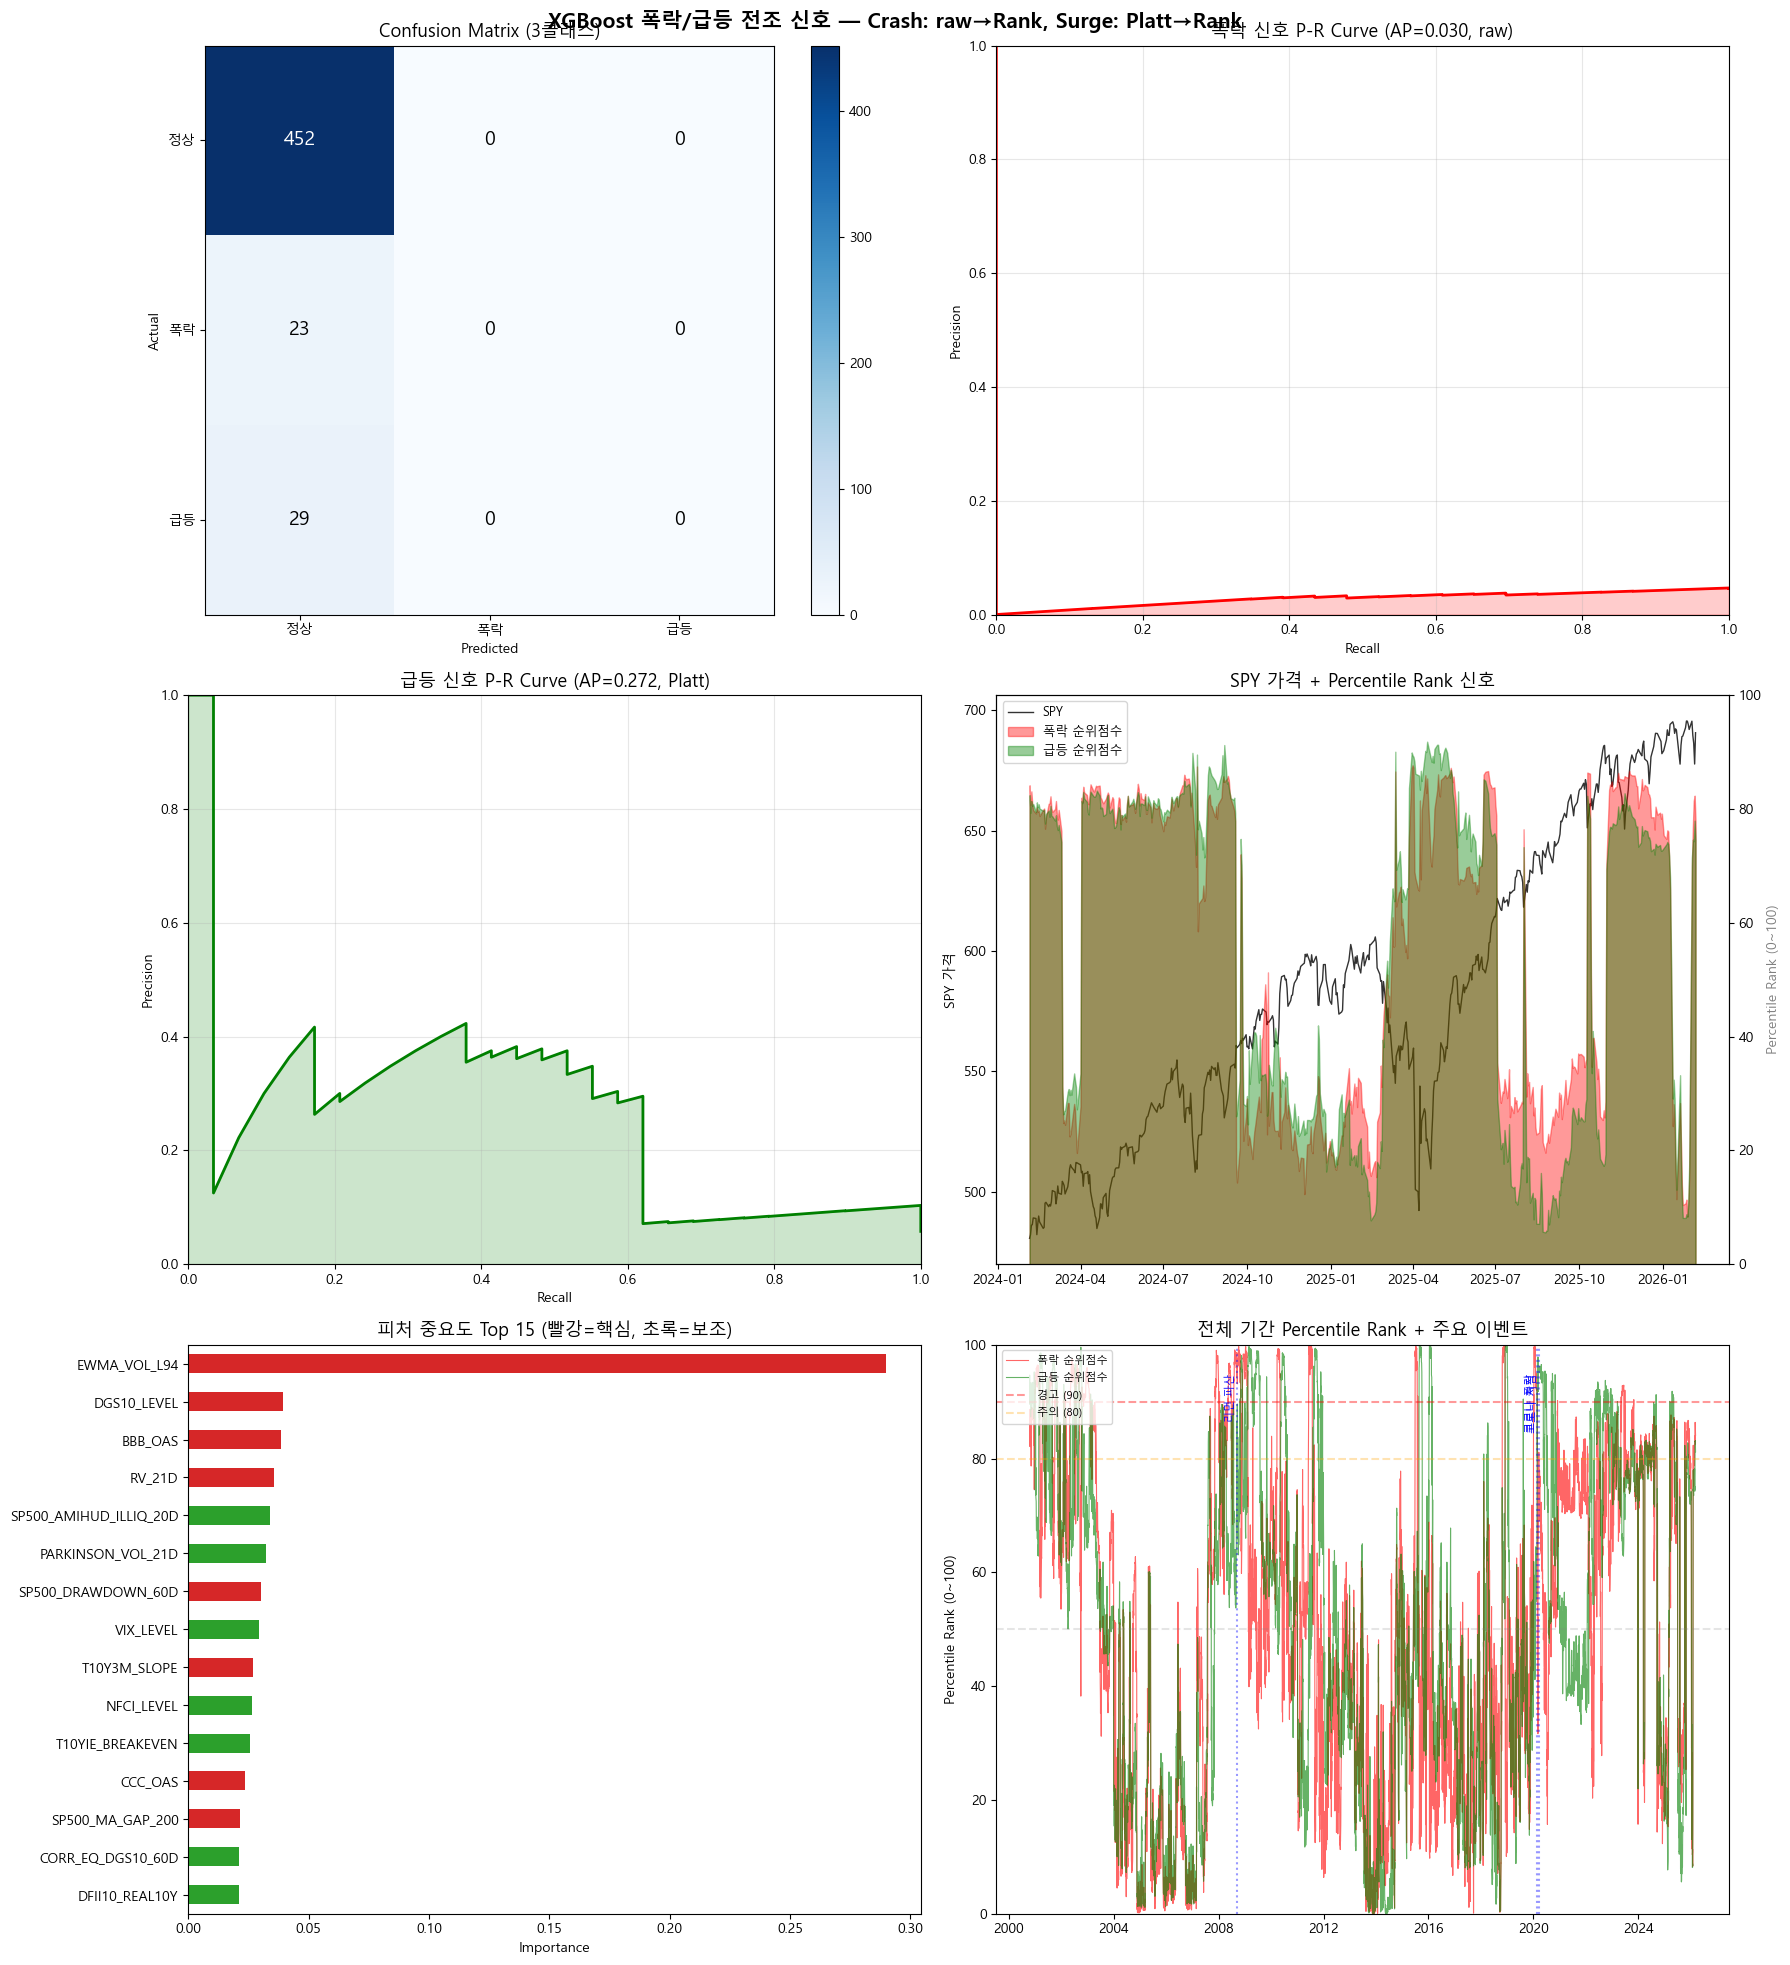


── 주요 이벤트 시점 신호 (Percentile Rank) ──
  2008-09-02: crash=98.7 (raw 97.4%), surge=59.7 (Platt 2.8%)
  2008-09-15: crash=94.2 (raw 89.1%), surge=86.5 (Platt 16.6%)
  2020-02-14: crash=92.1 (raw 63.6%), surge=62.5 (Platt 3.6%)
  2020-02-20: crash=92.2 (raw 65.0%), surge=63.3 (Platt 3.8%)
  2020-03-23: crash=75.9 (raw 9.1%), surge=95.9 (Platt 84.4%)
  2020-04-15: crash=66.1 (raw 4.4%), surge=96.1 (Platt 85.1%)
  2021-01-04: crash=77.9 (raw 10.3%), surge=56.0 (Platt 2.3%)


In [64]:
# ── Cell 5: 검증 & 5패널 시각화 (Crash: raw→Rank, Surge: Platt→Rank) ─────

# ── 홀드아웃 테스트셋 평가 (원래 모델) ──
X_test_s = scaler_final.transform(X_test)
y_proba_test_raw = model_final.predict_proba(X_test_s)
y_pred_test = model_final.predict(X_test_s)

CLASS_NAMES = ['정상(0)', '폭락전조(1)', '급등전조(2)']
print('=' * 60)
print('홀드아웃 테스트셋 Classification Report (원래 모델)')
print('=' * 60)
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES, digits=3))

macro_f1 = f1_score(y_test, y_pred_test, average='macro')
print(f'Macro F1-score: {macro_f1:.4f}  (기준: > 0.25)')

# ── 전체 기간 추론 ──
X_all_s = scaler_final.transform(df_full[ALL_FEATURES].values)
proba_all_raw = model_final.predict_proba(X_all_s)

# 원래 확률 (%)
crash_all_raw = pd.Series(proba_all_raw[:, 1] * 100, index=df_full.index)
surge_all_raw = pd.Series(proba_all_raw[:, 2] * 100, index=df_full.index)

# ── Platt Scaling: Surge만 적용 (Crash는 Platt weight 음수 → 스킵) ──
surge_platt = pd.Series(apply_platt(platt_surge, proba_all_raw[:, 2]) * 100, index=df_full.index)

# Platt 파라미터 확인
platt_crash_w = platt_crash.coef_[0][0]
print(f'\n  Platt crash w={platt_crash_w:.4f} ({"양수 ✅" if platt_crash_w > 0 else "음수 → Platt 스킵, raw 사용 ⚠️"})')
print(f'  Platt surge w={platt_surge.coef_[0][0]:.4f}')

# ── Percentile Rank 변환 (0~100) ──
# Crash: raw probability → Percentile Rank (Platt 없이)
# Surge: Platt 보정 → Percentile Rank
crash_all = crash_all_raw.rank(pct=True) * 100
surge_all = surge_platt.rank(pct=True) * 100

print(f'\n추론 범위: {df_full.index[0].date()} ~ {df_full.index[-1].date()} ({len(df_full)}행)')
print(f'\n── 변환 파이프라인 ──')
print(f'  폭락: raw 평균 {crash_all_raw.mean():.1f}% → (Platt 스킵) → rank {crash_all.mean():.1f}')
print(f'  급등: raw 평균 {surge_all_raw.mean():.1f}% → Platt {surge_platt.mean():.1f}% → rank {surge_all.mean():.1f}')

# ── 5패널 차트 ──
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('XGBoost 폭락/급등 전조 신호 — Crash: raw→Rank, Surge: Platt→Rank', fontsize=15, fontweight='bold')

# Panel 1: Confusion Matrix
ax = axes[0, 0]
cm = confusion_matrix(y_test, y_pred_test)
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix (3클래스)', fontsize=13)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['정상', '폭락', '급등'])
ax.set_yticklabels(['정상', '폭락', '급등'])
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=14)
fig.colorbar(im, ax=ax)

# Panel 2: 폭락 P-R Curve (raw probability 사용)
ax = axes[0, 1]
crash_true = (y_test == 1).astype(int)
prec_c, rec_c, _ = precision_recall_curve(crash_true, y_proba_test_raw[:, 1])
ap_c = average_precision_score(crash_true, y_proba_test_raw[:, 1])
ax.plot(rec_c, prec_c, 'r-', linewidth=2)
ax.fill_between(rec_c, prec_c, alpha=0.2, color='red')
ax.set_title(f'폭락 신호 P-R Curve (AP={ap_c:.3f}, raw)', fontsize=13)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.grid(True, alpha=0.3)

# Panel 3: 급등 P-R Curve (Platt 보정)
ax = axes[1, 0]
surge_true = (y_test == 2).astype(int)
surge_prob_cal = apply_platt(platt_surge, y_proba_test_raw[:, 2])
prec_s, rec_s, _ = precision_recall_curve(surge_true, surge_prob_cal)
ap_s = average_precision_score(surge_true, surge_prob_cal)
ax.plot(rec_s, prec_s, 'g-', linewidth=2)
ax.fill_between(rec_s, prec_s, alpha=0.2, color='green')
ax.set_title(f'급등 신호 P-R Curve (AP={ap_s:.3f}, Platt)', fontsize=13)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.grid(True, alpha=0.3)

# Panel 4: SPY 가격 + Percentile Rank
ax1 = axes[1, 1]
test_dates = test_df.index
ax1.plot(test_dates, close.reindex(test_dates), 'k-', linewidth=1, alpha=0.8, label='SPY')
ax1.set_title('SPY 가격 + Percentile Rank 신호', fontsize=13)
ax1.set_ylabel('SPY 가격', color='black')
ax2 = ax1.twinx()
ax2.fill_between(test_dates, crash_all.reindex(test_dates), alpha=0.4, color='red', label='폭락 순위점수')
ax2.fill_between(test_dates, surge_all.reindex(test_dates), alpha=0.4, color='green', label='급등 순위점수')
ax2.set_ylabel('Percentile Rank (0~100)', color='gray'); ax2.set_ylim([0, 100])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# Panel 5: 피처 중요도 Top 15
ax = axes[2, 0]
importances = model_final.feature_importances_
feat_imp = pd.Series(importances, index=ALL_FEATURES).sort_values(ascending=True)
top15 = feat_imp.tail(15)
colors = ['#d62728' if f in CORE_FEATURES else '#2ca02c' for f in top15.index]
top15.plot(kind='barh', ax=ax, color=colors)
ax.set_title('피처 중요도 Top 15 (빨강=핵심, 초록=보조)', fontsize=13)
ax.set_xlabel('Importance')

# Panel 6: 전체 기간 Percentile Rank + 주요 이벤트
ax = axes[2, 1]
ax.plot(df_full.index, crash_all, 'r-', alpha=0.6, linewidth=0.8, label='폭락 순위점수')
ax.plot(df_full.index, surge_all, 'g-', alpha=0.6, linewidth=0.8, label='급등 순위점수')
ax.axhline(90, color='red', linestyle='--', alpha=0.4, label='경고 (90)')
ax.axhline(80, color='orange', linestyle='--', alpha=0.3, label='주의 (80)')
ax.axhline(50, color='gray', linestyle='--', alpha=0.2)
events = {'2008-09-15': '리먼 파산', '2020-02-20': '코로나 폭락', '2020-03-23': '코로나 저점'}
for date_str, label_text in events.items():
    dt = pd.Timestamp(date_str)
    if dt in df_full.index:
        ax.axvline(dt, color='blue', alpha=0.4, linestyle=':')
        ax.annotate(label_text, xy=(dt, 95), fontsize=8, color='blue', rotation=90, va='top', ha='right')
ax.set_title('전체 기간 Percentile Rank + 주요 이벤트', fontsize=13)
ax.set_ylabel('Percentile Rank (0~100)'); ax.legend(loc='upper left', fontsize=8); ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

# ── 주요 이벤트 시점 (Percentile Rank) ──
print('\n── 주요 이벤트 시점 신호 (Percentile Rank) ──')
check_dates = ['2008-09-01', '2008-09-15', '2020-02-14', '2020-02-20',
               '2020-03-23', '2020-04-15', '2021-01-04']
for d in check_dates:
    dt = pd.Timestamp(d)
    idx = df_full.index.get_indexer([dt], method='nearest')[0]
    actual_dt = df_full.index[idx]
    cs = crash_all.loc[actual_dt]
    ss = surge_all.loc[actual_dt]
    cs_raw = crash_all_raw.loc[actual_dt]
    ss_p = surge_platt.loc[actual_dt]
    print(f'  {actual_dt.date()}: crash={cs:.1f} (raw {cs_raw:.1f}%), surge={ss:.1f} (Platt {ss_p:.1f}%)')

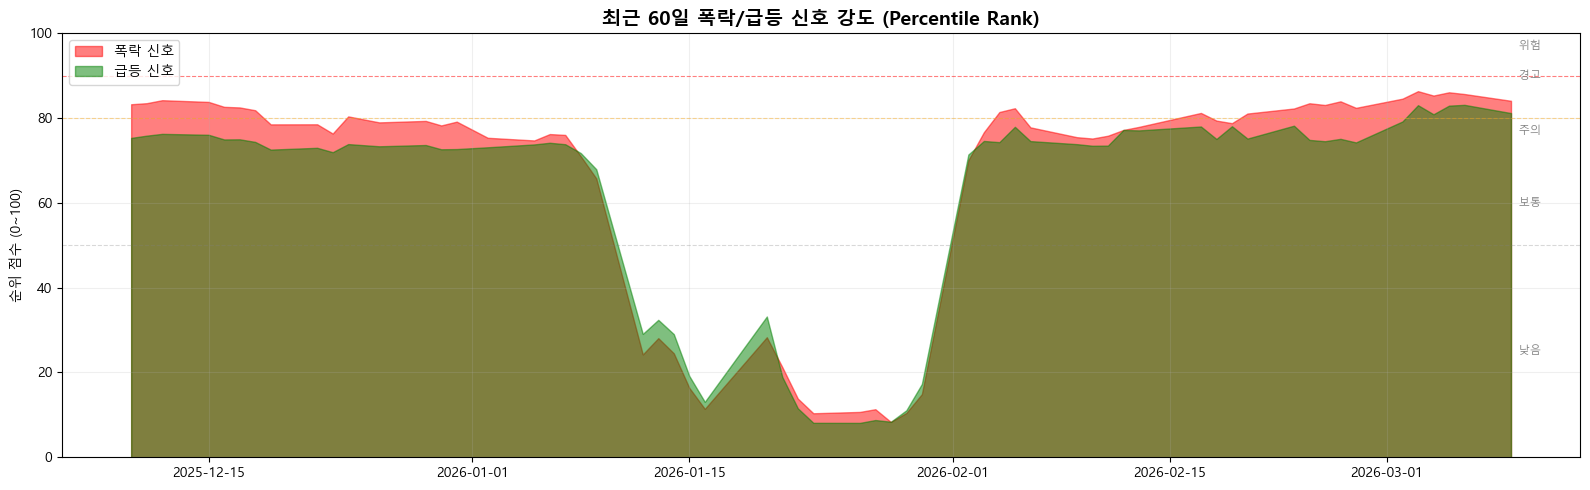

── 최근 10일 신호 테이블 ──
        날짜  crash_score crash_grade  surge_score surge_grade
2026-02-24         83.5          주의         74.9          주의
2026-02-25         83.1          주의         74.5          주의
2026-02-26         84.0          주의         75.1          주의
2026-02-27         82.4          주의         74.3          주의
2026-03-02         84.6          주의         79.2          주의
2026-03-03         86.4          경고         83.1          주의
2026-03-04         85.3          경고         80.9          주의
2026-03-05         86.1          경고         82.9          주의
2026-03-06         85.7          경고         83.1          주의
2026-03-09         84.1          주의         81.2          주의

최신 날짜: 2026-03-09
  폭락 신호: 84.1점 (주의) — 과거 대비 상위 16%
  급등 신호: 81.2점 (주의) — 과거 대비 상위 19%

안정기(2013~2019) 평균:
  crash_score: 32.4  (기준: < 55)
  surge_score: 33.8  (기준: < 55)

── 위기 시점 검증 ──
  ✅ 리먼 파산 (2008-09-15): crash_score=94.2 (기준: > 90)
  ✅ 코로나 폭락 직전 (2020-02-20): crash_score=92.2 (기준: > 90)
  ✅ 코로나 반등기 

In [65]:
# ── Cell 6: 신호 강도 & 등급 (Percentile Rank 기반) ────────────

# ── 점수: Platt 보정 확률의 Percentile Rank (0~100) ──
crash_score = crash_all
surge_score = surge_all

# ── 등급 매핑 (Percentile 기반) ──
def grade(score):
    """0~100 percentile rank -> 등급"""
    if score < 50:
        return '낮음'
    elif score < 70:
        return '보통'
    elif score < 85:
        return '주의'
    elif score < 95:
        return '경고'
    else:
        return '위험'

crash_grade = crash_score.apply(grade)
surge_grade = surge_score.apply(grade)

# ── 최근 60일 듀얼 신호 타임라인 ──
last60 = df_full.index[-60:]

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(last60, crash_score.reindex(last60), alpha=0.5, color='red', label='폭락 신호')
ax.fill_between(last60, surge_score.reindex(last60), alpha=0.5, color='green', label='급등 신호')
ax.axhline(90, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
ax.axhline(80, color='orange', linestyle='--', alpha=0.4, linewidth=0.8)
ax.axhline(50, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
ax.set_title('최근 60일 폭락/급등 신호 강도 (Percentile Rank)', fontsize=14, fontweight='bold')
ax.set_ylabel('순위 점수 (0~100)')
ax.set_ylim([0, 100])
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)

for y, txt in [(25, '낮음'), (60, '보통'), (77, '주의'), (90, '경고'), (97, '위험')]:
    ax.text(last60[-1], y, f'  {txt}', fontsize=8, color='gray', va='center')

plt.tight_layout()
plt.show()

# ── 최근 10일 신호 테이블 ──
last10 = df_full.index[-10:]
table = pd.DataFrame({
    '날짜': last10.date,
    'crash_score': crash_score.reindex(last10).round(1).values,
    'crash_grade': crash_grade.reindex(last10).values,
    'surge_score': surge_score.reindex(last10).round(1).values,
    'surge_grade': surge_grade.reindex(last10).values,
})
print('── 최근 10일 신호 테이블 ──')
print(table.to_string(index=False))

# ── 최신 점수 + 등급 출력 ──
latest = df_full.index[-1]
cs_latest = crash_score.loc[latest]
ss_latest = surge_score.loc[latest]
print(f'\n{"=" * 50}')
print(f'최신 날짜: {latest.date()}')
print(f'  폭락 신호: {cs_latest:.1f}점 ({grade(cs_latest)}) — 과거 대비 상위 {100-cs_latest:.0f}%')
print(f'  급등 신호: {ss_latest:.1f}점 ({grade(ss_latest)}) — 과거 대비 상위 {100-ss_latest:.0f}%')
print(f'{"=" * 50}')

# ── 안정기 평균 확인 ──
stable_mask = (df_full.index >= '2013-01-01') & (df_full.index <= '2019-12-31')
if stable_mask.any():
    stable_crash = crash_score[stable_mask].mean()
    stable_surge = surge_score[stable_mask].mean()
    print(f'\n안정기(2013~2019) 평균:')
    print(f'  crash_score: {stable_crash:.1f}  (기준: < 55)')
    print(f'  surge_score: {stable_surge:.1f}  (기준: < 55)')

# ── 위기 시점 검증 ──
print(f'\n── 위기 시점 검증 ──')
crisis_checks = [
    ('2008-09-15', 'crash', 90, '리먼 파산'),
    ('2020-02-20', 'crash', 90, '코로나 폭락 직전'),
    ('2020-04-15', 'surge', 80, '코로나 반등기'),
]
for d, signal, threshold, desc in crisis_checks:
    dt = pd.Timestamp(d)
    idx = df_full.index.get_indexer([dt], method='nearest')[0]
    actual_dt = df_full.index[idx]
    val = crash_score.loc[actual_dt] if signal == 'crash' else surge_score.loc[actual_dt]
    status = '✅' if val >= threshold else '❌'
    print(f'  {status} {desc} ({actual_dt.date()}): {signal}_score={val:.1f} (기준: > {threshold})')
